In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [ ]:
import os, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

# --- Reproducibility ---
# Setting a fixed seed means every time you run this notebook
# you get the SAME random numbers → same train/val/test split
# same weight initialization → fully reproducible results
SEED = 42
def set_seed(seed=SEED):
    random.seed(seed)          # Python's built-in random
    np.random.seed(seed)       # NumPy random
    torch.manual_seed(seed)    # PyTorch CPU random
    torch.cuda.manual_seed_all(seed)  # PyTorch GPU random
    torch.backends.cudnn.deterministic = True  # makes convolutions deterministic

set_seed()

# Use GPU if available, otherwise CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

In [ ]:
# ---------------------------------------------------------------
# HYPERPARAMETERS — keep these IDENTICAL to your Task 2 notebook
# This is required by the assignment for fair comparison
# ---------------------------------------------------------------

DATA_DIR    = Path('/kaggle/input/datasets/obulisainaren/multi-cancer/Multi Cancer/Multi Cancer/Brain Cancer')
IMG_SIZE    = 224       # resize every image to 224×224 pixels
BATCH_SIZE  = 32        # 32 images processed at once during training
LR          = 1e-3      # learning rate = how big each weight update step is
NUM_EPOCHS  = 50        # maximum training rounds (increased to 50)
PATIENCE    = 5         # stop early if val loss doesn't improve for 5 epochs
TRAIN_SPLIT = 0.80      # 80% of data → training
VAL_SPLIT   = 0.10      # 10% → validation (monitor overfitting)
TEST_SPLIT  = 0.10      # 10% → final test (never seen during training)
WEIGHT_DECAY= 1e-4      # L2 regularization to prevent overfitting

# Auto-detect class folder names (glioma, meningioma, etc.)
CLASS_NAMES = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print(f'Number of classes : {NUM_CLASSES}')
print(f'Class names       : {CLASS_NAMES}')
print(f'Train/Val/Test    : {TRAIN_SPLIT}/{VAL_SPLIT}/{TEST_SPLIT}')
print(f'Max Epochs        : {NUM_EPOCHS}')

In [ ]:

# ---------------------------------------------------------------
# TRANSFORMS
# Training data gets AUGMENTATION (artificial variations of images)
# This helps the model generalize — it won't just memorize training images
# ---------------------------------------------------------------

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),   # resize to 224×224
    transforms.RandomHorizontalFlip(p=0.5),    # flip image left-right (50% chance)
    transforms.RandomRotation(degrees=15),     # rotate up to ±15 degrees
    transforms.ColorJitter(brightness=0.2,     # randomly change brightness
                           contrast=0.2,       # and contrast slightly
                           saturation=0.1),
    transforms.RandomAffine(degrees=0,
                            translate=(0.05, 0.05)),  # shift image slightly
    transforms.ToTensor(),                     # convert PIL image → PyTorch tensor [0,1]
    transforms.Normalize(                      # normalize using ImageNet stats
        mean=[0.485, 0.456, 0.406],            # these values are standard practice
        std =[0.229, 0.224, 0.225])            # even for non-ImageNet datasets
])

# Val/Test images: NO augmentation — we want real, unmodified evaluation
val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225])
])

# Load entire dataset from folder
# ImageFolder expects subfolders named by class (glioma/, meningioma/, etc.)
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

# Calculate split sizes
n_total = len(full_dataset)
n_train = int(TRAIN_SPLIT * n_total)   # e.g. 70% of total
n_val   = int(VAL_SPLIT   * n_total)   # e.g. 15%
n_test  = n_total - n_train - n_val    # remaining 15%

# Randomly split into train / val / test subsets
# generator=... ensures same split every run (reproducibility)
train_ds, val_ds, test_ds = random_split(
    full_dataset, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val/test transforms to val and test datasets
# (we override the transform only for these subsets)
val_ds.dataset  = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)
test_ds.dataset = datasets.ImageFolder(DATA_DIR, transform=val_test_transforms)

# DataLoaders batch the data and feed it to the model
# shuffle=True for training (randomize order each epoch)
# num_workers=2 → uses 2 background threads to load images faster
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Total images : {n_total}')
print(f'Training     : {n_train}')
print(f'Validation   : {n_val}')
print(f'Test         : {n_test}')

In [ ]:
# ---------------------------------------------------------------
# BUILDING THE CUSTOM CNN FROM SCRATCH
#
# A ConvBlock is the repeated unit of a CNN:
#   Conv2d → BatchNorm → ReLU → Conv2d → BatchNorm → ReLU → MaxPool
#
# Conv2d:      scans the image with a small filter to detect features
#              (edges, textures, shapes)
# BatchNorm:   normalizes outputs so training is stable and faster
# ReLU:        activation function — sets negatives to 0 (adds non-linearity)
# MaxPool:     reduces spatial size by half (keeps strongest feature in region)
# ---------------------------------------------------------------

class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, pool=True):
        # in_ch  = number of input channels (e.g. 3 for RGB, 32 for next block)
        # out_ch = number of filters to learn (32, 64, 128, etc.)
        # pool   = whether to halve the spatial size with MaxPool
        super().__init__()
        layers = [
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            # kernel_size=3 → 3×3 filter slides over the image
            # padding=1 → adds 1 pixel border so output size matches input size
            # bias=False → BatchNorm handles the bias, so we don't need it here
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),   # inplace=True saves memory
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        ]
        if pool:
            layers.append(nn.MaxPool2d(2, 2))
            # kernel=2, stride=2 → cuts width and height in half
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)


class CustomCNN(nn.Module):
    """
    Architecture overview:
    Input: (Batch, 3, 224, 224)   ← 3-channel RGB image
      Block 1: 3→32   + pool  → (B, 32,  112, 112)
      Block 2: 32→64  + pool  → (B, 64,   56,  56)
      Block 3: 64→128 + pool  → (B, 128,  28,  28)
      Block 4: 128→256+ pool  → (B, 256,  14,  14)
      Block 5: 256→512+ pool  → (B, 512,   7,   7)
      AdaptiveAvgPool          → (B, 512,   1,   1)
      Flatten                  → (B, 512)
      Linear 512→256 + ReLU
      Dropout
      Linear 256→num_classes   → final prediction
    """
    def __init__(self, num_classes=4, dropout=0.5):
        super().__init__()

        # Feature extractor: stacked ConvBlocks
        # Each block learns increasingly complex features:
        # Block1 = edges/corners, Block2 = textures, Block3+ = shapes/structures
        self.features = nn.Sequential(
            ConvBlock(3,   32,  pool=True),
            ConvBlock(32,  64,  pool=True),
            ConvBlock(64,  128, pool=True),
            ConvBlock(128, 256, pool=True),
            ConvBlock(256, 512, pool=True),
        )

        # Reduces any spatial size to 1×1 (makes model flexible to image sizes)
        self.pool = nn.AdaptiveAvgPool2d(1)

        # Classifier head: takes the 512 feature vector → class scores
        self.classifier = nn.Sequential(
            nn.Flatten(),             # (B,512,1,1) → (B,512)
            nn.Linear(512, 256),      # fully connected: 512 inputs → 256 outputs
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),      # randomly zeroes 50% of neurons during training
                                      # → prevents the model from memorizing training data
            nn.Linear(256, num_classes)  # final layer: 256 → number of cancer classes
        )

    def forward(self, x):
        x = self.features(x)    # extract features
        x = self.pool(x)        # global average pooling
        return self.classifier(x)  # classify


# Create model and send to GPU/CPU
model = CustomCNN(num_classes=NUM_CLASSES).to(DEVICE)

# Count trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model architecture:\n{model}')
print(f'\nTotal trainable parameters: {total_params:,}')

In [ ]:
# ---------------------------------------------------------------
# CrossEntropyLoss: standard loss for multi-class classification
#   It measures how wrong the model's predictions are
#   Lower loss = model is more confident and correct
#
# Adam optimizer: updates the model weights after each batch
#   It adapts the learning rate per parameter automatically
#   weight_decay adds L2 penalty → keeps weights small → less overfitting
#
# ReduceLROnPlateau scheduler:
#   If val loss doesn't improve for 3 epochs → halve the learning rate
#   This helps the model fine-tune more carefully later in training
# ---------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # multiply LR by 0.5 when triggered
    patience=3,       # wait 3 epochs before reducing
    verbose=True      # print when LR is reduced
)

print('Loss, optimizer, and scheduler are ready.')

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',       # we want to minimize val loss
    factor=0.5,       # new_lr = old_lr × 0.5 when triggered
    patience=3,       # wait 3 epochs of no improvement before reducing
)

print('Loss, optimizer, and scheduler are ready.')

# Optional: check your PyTorch version
print(f'PyTorch version: {torch.__version__}')

In [10]:
# ---------------------------------------------------------------
# HELPER FUNCTIONS
# train_one_epoch: runs through all training batches once
# evaluate:        runs through val/test batches (no gradient updates)
# ---------------------------------------------------------------

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()   # puts model in TRAINING mode (enables Dropout, BatchNorm updates)
    running_loss, correct, total = 0.0, 0, 0

    for imgs, labels in loader:
        imgs   = imgs.to(DEVICE)    # move images to GPU
        labels = labels.to(DEVICE)  # move labels to GPU

        optimizer.zero_grad()       # clear gradients from previous batch

        outputs = model(imgs)       # forward pass: get predictions
        loss    = criterion(outputs, labels)  # calculate how wrong we are

        loss.backward()             # backpropagation: compute gradients
        optimizer.step()            # update weights using gradients

        running_loss += loss.item() * imgs.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += imgs.size(0)

    return running_loss / total, correct / total   # avg loss, accuracy


def evaluate(model, loader, criterion):
    model.eval()    # EVALUATION mode: disables Dropout, freezes BatchNorm
    running_loss, correct, total = 0.0, 0, 0

    with torch.no_grad():   # no gradient computation needed → saves memory & speed
        for imgs, labels in loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            running_loss += loss.item() * imgs.size(0)
            correct      += (outputs.argmax(1) == labels).sum().item()
            total        += imgs.size(0)

    return running_loss / total, correct / total


# ---------------------------------------------------------------
# MAIN TRAINING LOOP
# ---------------------------------------------------------------

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc':  [], 'val_acc':  []
}

best_val_loss    = float('inf')   # track best val loss (start at infinity)
patience_counter = 0              # counts epochs without improvement
best_model_path  = 'best_custom_cnn.pth'

train_start = time.time()   # record start time

for epoch in range(NUM_EPOCHS):
    t_loss, t_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    v_loss, v_acc = evaluate(model, val_loader, criterion)

    scheduler.step(v_loss)   # possibly reduce LR

    # save to history for plotting later
    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    print(f'Epoch [{epoch+1:02d}/{NUM_EPOCHS}]  '
          f'Train Loss: {t_loss:.4f}  Train Acc: {t_acc:.4f}  '
          f'Val Loss: {v_loss:.4f}  Val Acc: {v_acc:.4f}')

    # --- Early Stopping ---
    # If val loss improved → save this model as the best one
    if v_loss < best_val_loss:
        best_val_loss    = v_loss
        patience_counter = 0
        torch.save(model.state_dict(), best_model_path)
        print(f'  ✓ Best model saved (val_loss={v_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{PATIENCE})')
        # Only stop if we've trained at least 5 epochs (assignment requirement)
        if patience_counter >= PATIENCE and epoch + 1 >= 5:
            print(f'Early stopping triggered at epoch {epoch+1}')
            break

train_time = time.time() - train_start
print(f'\nTotal Training Time: {train_time:.1f} seconds')

Epoch [01/50]  Train Loss: 0.3144  Train Acc: 0.8810  Val Loss: 1.9814  Val Acc: 0.5027
  ✓ Best model saved (val_loss=1.9814)
Epoch [02/50]  Train Loss: 0.2690  Train Acc: 0.8958  Val Loss: 0.2538  Val Acc: 0.8967
  ✓ Best model saved (val_loss=0.2538)
Epoch [03/50]  Train Loss: 0.2474  Train Acc: 0.9085  Val Loss: 0.2557  Val Acc: 0.8960
  No improvement (1/5)
Epoch [04/50]  Train Loss: 0.2105  Train Acc: 0.9238  Val Loss: 0.6784  Val Acc: 0.7620
  No improvement (2/5)
Epoch [05/50]  Train Loss: 0.2038  Train Acc: 0.9239  Val Loss: 0.4093  Val Acc: 0.8307
  No improvement (3/5)
Epoch [06/50]  Train Loss: 0.1862  Train Acc: 0.9313  Val Loss: 0.2405  Val Acc: 0.9020
  ✓ Best model saved (val_loss=0.2405)
Epoch [07/50]  Train Loss: 0.1717  Train Acc: 0.9379  Val Loss: 0.8100  Val Acc: 0.7580
  No improvement (1/5)
Epoch [08/50]  Train Loss: 0.1701  Train Acc: 0.9379  Val Loss: 0.3417  Val Acc: 0.8607
  No improvement (2/5)
Epoch [09/50]  Train Loss: 0.1514  Train Acc: 0.9463  Val Loss: 

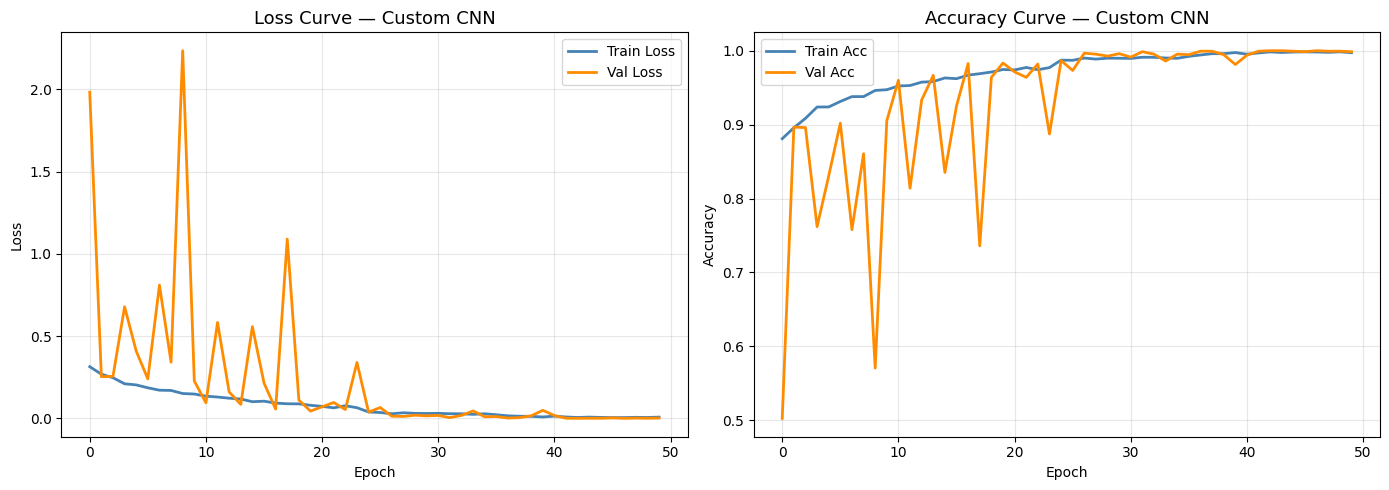

Saved: task3_learning_curves.png


In [11]:
# Visualize training progress
# If val_loss keeps going UP while train_loss goes DOWN → overfitting
# Good training: both curves go down together and converge

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', color='steelblue',  lw=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   color='darkorange', lw=2)
axes[0].set_title('Loss Curve — Custom CNN', fontsize=13)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history['train_acc'], label='Train Acc', color='steelblue',  lw=2)
axes[1].plot(history['val_acc'],   label='Val Acc',   color='darkorange', lw=2)
axes[1].set_title('Accuracy Curve — Custom CNN', fontsize=13)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('task3_learning_curves.png', dpi=150)
plt.show()
print('Saved: task3_learning_curves.png')

In [12]:
# Load the BEST saved model (not the last epoch — the best val_loss epoch)
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

model.eval()
all_preds, all_labels, all_probs = [], [], []

test_start = time.time()

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs    = imgs.to(DEVICE)
        outputs = model(imgs)

        # softmax converts raw scores (logits) → probabilities that sum to 1
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()   # predicted class index

        all_probs.append(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

test_time  = time.time() - test_start
all_probs  = np.vstack(all_probs)   # shape: (num_test_samples, num_classes)
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# --- Compute all required metrics ---
acc       = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall    = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1        = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
auc       = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='weighted')
# OvR = One-vs-Rest: calculates AUC for each class against all others, then averages

print('='*55)
print('     TASK 3 — Custom CNN — Test Results')
print('='*55)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Precision : {precision:.4f}')
print(f'  Recall    : {recall:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  AUC (OvR) : {auc:.4f}')
print(f'  Train Time: {train_time:.1f}s')
print(f'  Test Time : {test_time:.4f}s')
print('='*55)
print('\nDetailed Per-Class Report:')
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

     TASK 3 — Custom CNN — Test Results
  Accuracy  : 1.0000  (100.00%)
  Precision : 1.0000
  Recall    : 1.0000
  F1-Score  : 1.0000
  AUC (OvR) : 1.0000
  Train Time: 4150.3s
  Test Time : 13.3124s

Detailed Per-Class Report:
              precision    recall  f1-score   support

brain_glioma       1.00      1.00      1.00       498
 brain_menin       1.00      1.00      1.00       474
 brain_tumor       1.00      1.00      1.00       528

    accuracy                           1.00      1500
   macro avg       1.00      1.00      1.00      1500
weighted avg       1.00      1.00      1.00      1500



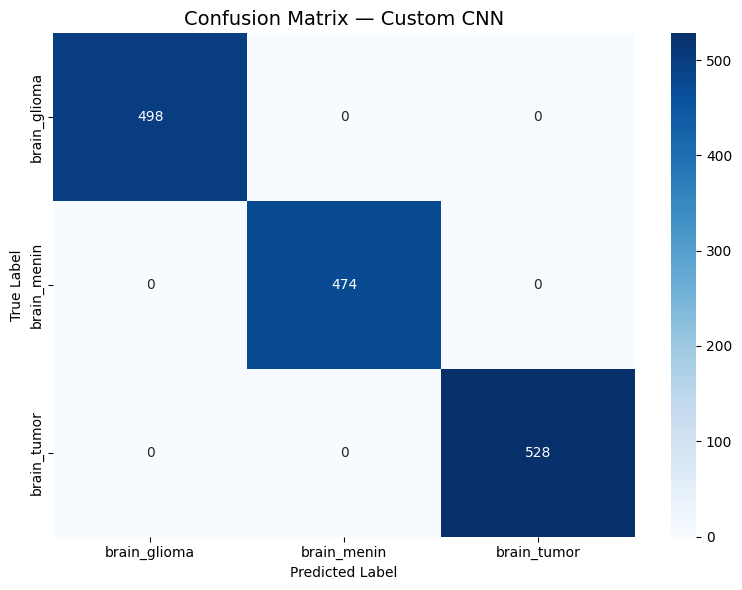

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,          # show numbers inside cells
    fmt='d',             # integer format
    cmap='Blues',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)
plt.title('Confusion Matrix — Custom CNN', fontsize=14)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('task3_confusion_matrix.png', dpi=150)
plt.show()

# How to read this:
# Diagonal cells = correct predictions
# Off-diagonal cells = mistakes (which class is confused with which)

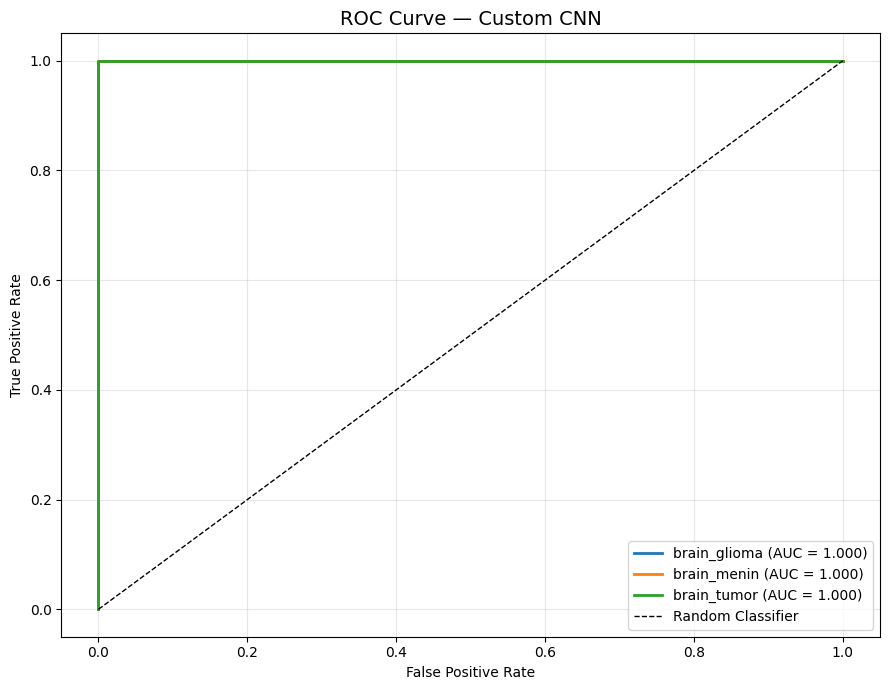

In [14]:
# One-vs-Rest ROC curve: for each class, plot True Positive Rate vs False Positive Rate
# AUC = Area Under Curve — closer to 1.0 = better

y_bin = label_binarize(all_labels, classes=list(range(NUM_CLASSES)))
# converts labels like [0,1,2,3] → one-hot [[1,0,0,0],[0,1,0,0],...]

plt.figure(figsize=(9, 7))
colors = plt.cm.tab10.colors

for i, cls in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    auc_i       = roc_auc_score(y_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'{cls} (AUC = {auc_i:.3f})')

plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Custom CNN', fontsize=14)
plt.legend(loc='lower right'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task3_roc_curve.png', dpi=150)
plt.show()

In [15]:
import json

# Save predictions and metrics so Task 4 can compare against Task 3
task3_results = {
    'model'      : 'Custom CNN',
    'accuracy'   : float(acc),
    'precision'  : float(precision),
    'recall'     : float(recall),
    'f1'         : float(f1),
    'auc'        : float(auc),
    'train_time' : float(train_time),
    'test_time'  : float(test_time),
    'all_preds'  : all_preds.tolist(),
    'all_labels' : all_labels.tolist(),
    'all_probs'  : all_probs.tolist()
}

with open('task3_results.json', 'w') as f:
    json.dump(task3_results, f)

print('✓ Saved task3_results.json — use this in Task 4 for comparison!')

✓ Saved task3_results.json — use this in Task 4 for comparison!
